In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
#Data Cleaning

pd.set_option("display.max_columns", 22)
df_eda = pd.read_csv('heart_attack_dataset .csv')
df_eda.set_index('patient_id', inplace =True)

num_cols = df_eda.select_dtypes(include = 'number').columns
df_eda[num_cols] = df_eda[num_cols].fillna(df_eda[num_cols].median())

cat_cols = df_eda.select_dtypes(include = 'object').columns
for col in cat_cols:
    df_eda[col] = df_eda[col].fillna(df_eda[col].mode()[0])

In [3]:
scores = []
for _, row in df_eda.iterrows() : 
    score = 0
    
    if row['fasting_blood_sugar'] > 0.5 :
        score += 1
    if row['family_history'] > 0 :
        score += 1
    if row['smoking_status'] == 'Current' :
        score += 1
    if row['smoking_status'] == 'Former' :
        score += 0.5
    scores.append(score)
    
df_eda['Total_Risk_Factor'] = scores

In [4]:
df_eda

,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level,heart_attack_risk,Total_Risk_Factor
patient_id,,,,,,,,,,,,,,,,,,,,,,
1,59,Male,Asymptomatic,105.0,154.0,0.0,ST-T Abnormality,186.0,1,1.0,Flat,1,Fixed Defect,23.5,Former,Heavy,Moderate,1,1,6.0,0,1.5
2,50,Male,Non-anginal Pain,102.0,180.0,0.0,Normal,183.0,0,2.9,Flat,0,Reversible Defect,19.3,Never,Moderate,High,0,0,8.0,0,0.0
3,61,Male,Atypical Angina,117.0,213.0,1.0,Normal,161.0,0,0.0,Flat,1,Fixed Defect,30.5,Never,Moderate,Low,1,1,2.0,1,2.0
4,73,Female,Atypical Angina,121.0,208.0,1.0,Normal,150.0,0,1.0,Up,0,Normal,28.6,Former,Moderate,Moderate,0,0,4.0,0,1.5
5,49,Male,Non-anginal Pain,106.0,157.0,0.0,Normal,185.0,0,0.3,Flat,0,Reversible Defect,21.4,Former,Moderate,Moderate,0,0,5.0,0,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6996,48,Female,Atypical Angina,108.0,127.0,1.0,Normal,167.0,0,0.3,Up,1,Normal,30.0,Current,Moderate,High,0,0,10.0,0,2.0
6997,63,Male,Non-anginal Pain,107.0,194.0,0.0,Left Ventricular Hypertrophy,159.0,0,0.4,Up,0,Fixed Defect,24.8,Current,Non-drinker,High,1,0,2.0,0,2.0
6998,45,Male,Asymptomatic,98.0,119.0,0.0,Left Ventricular Hypertrophy,161.0,0,3.4,Down,0,Normal,18.7,Current,Heavy,High,1,0,1.0,1,2.0


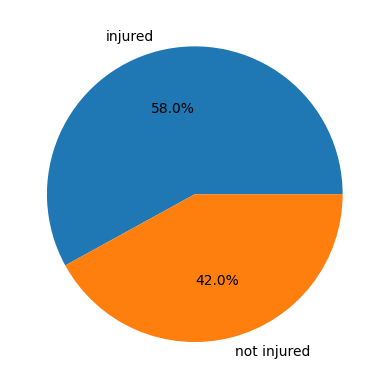

In [5]:
#1
heart_attack_risk_pourcentage = df_eda['heart_attack_risk'].value_counts(normalize = True)
plt.pie(heart_attack_risk_pourcentage , labels =['injured' , 'not injured'], autopct='%1.1f%%');

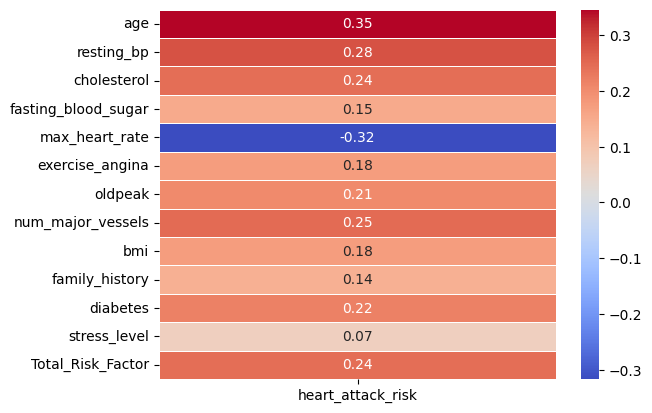

In [6]:
#2
numeric_df = df_eda.select_dtypes(include ='number')
corr = numeric_df.corr()[['heart_attack_risk']].drop('heart_attack_risk')
sns.heatmap(corr, annot = True, cmap = 'coolwarm' , fmt = '.2f' , linewidths = 0.5);

In [7]:
#3
results = []

cat_cols = df_eda.select_dtypes(include="object").columns

for col in cat_cols:
    rates = df_eda.groupby(col)["heart_attack_risk"].mean()

    for category, rate in rates.items():
        results.append({
            "Feature": col,
            "Category": category,
            "Heart_Attack_Rate": rate
        })

results_df = pd.DataFrame(results)

results_df

,Feature,Category,Heart_Attack_Rate
0,gender,Female,0.412808
1,gender,Male,0.425537
2,chest_pain_type,Asymptomatic,0.363680
3,chest_pain_type,Atypical Angina,0.441441
4,chest_pain_type,Non-anginal Pain,0.413135
5,chest_pain_type,Typical Angina,0.501650
6,resting_ecg,Left Ventricular Hypertrophy,0.422570
7,resting_ecg,Normal,0.418476
8,resting_ecg,ST-T Abnormality,0.421601
9,st_slope,Down,0.508704


In [8]:
#4
results = []
cat_cols = df_eda.select_dtypes(include="number").columns
for col in cat_cols :
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = numeric_df[
    (numeric_df[col] < Q1 - 1.5 * IQR) |
    (numeric_df[col] > Q3 + 1.5 * IQR)
    ]
    results.append({
    'col' : col ,
    'Outliers' : len(outliers)
})
results_df = pd.DataFrame(results)

results_df

,col,Outliers
0,age,33
1,resting_bp,69
2,cholesterol,68
3,fasting_blood_sugar,1721
4,max_heart_rate,24
5,exercise_angina,0
6,oldpeak,269
7,num_major_vessels,593
8,bmi,37
9,family_history,0


<Axes: >

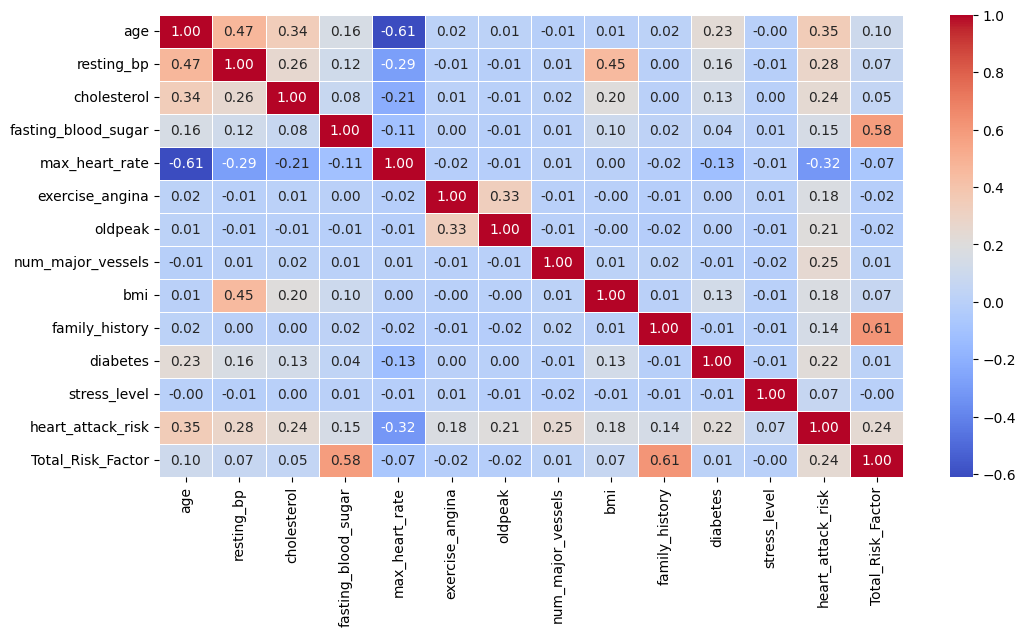

In [9]:
#5
numerica_df = df_eda.select_dtypes(include="number")
corr_matrix = numerica_df.corr()
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix,
           annot = True,
           cmap = 'coolwarm',
           fmt = '.2f',
           linewidths = 0.5)

<Axes: xlabel='age', ylabel='max_heart_rate'>

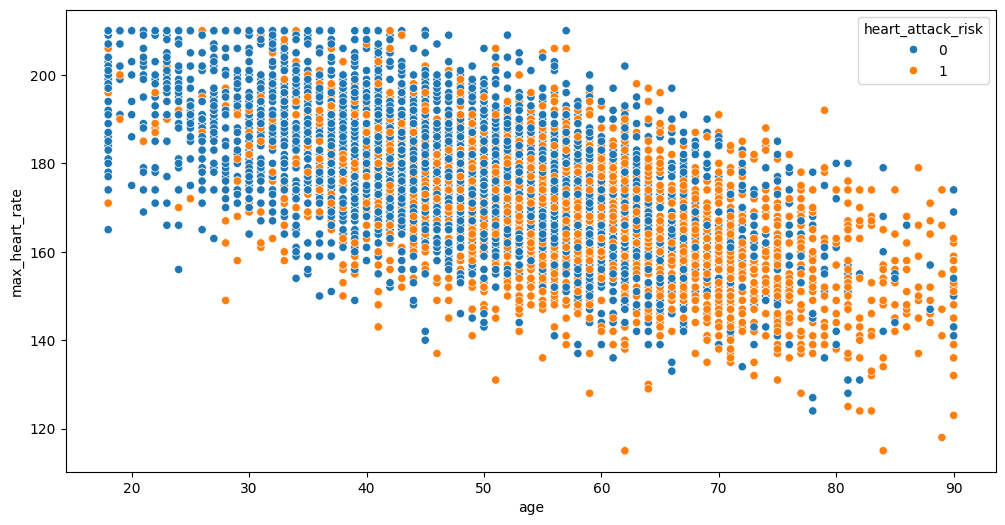

In [10]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data = df_eda ,
                x = 'age' , 
                y = 'max_heart_rate' , 
                hue = 'heart_attack_risk')

In [11]:
df_ml = pd.get_dummies(df_eda ,drop_first = True ,  dtype = int )

In [12]:
df_ml

,age,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_angina,oldpeak,num_major_vessels,bmi,family_history,diabetes,...,resting_ecg_ST-T Abnormality,st_slope_Flat,st_slope_Up,thalassemia_Normal,thalassemia_Reversible Defect,smoking_status_Former,smoking_status_Never,alcohol_consumption_Moderate,alcohol_consumption_Non-drinker,physical_activity_Low,physical_activity_Moderate
patient_id,,,,,,,,,,,,,,,,,,,,,,,
1,59,105.0,154.0,0.0,186.0,1,1.0,1,23.5,1,1,...,1,1,0,0,0,1,0,0,0,0,1
2,50,102.0,180.0,0.0,183.0,0,2.9,0,19.3,0,0,...,0,1,0,0,1,0,1,1,0,0,0
3,61,117.0,213.0,1.0,161.0,0,0.0,1,30.5,1,1,...,0,1,0,0,0,0,1,1,0,1,0
4,73,121.0,208.0,1.0,150.0,0,1.0,0,28.6,0,0,...,0,0,1,1,0,1,0,1,0,0,1
5,49,106.0,157.0,0.0,185.0,0,0.3,0,21.4,0,0,...,0,1,0,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6996,48,108.0,127.0,1.0,167.0,0,0.3,1,30.0,0,0,...,0,0,1,1,0,0,0,1,0,0,0
6997,63,107.0,194.0,0.0,159.0,0,0.4,0,24.8,1,0,...,0,0,1,0,0,0,0,0,1,0,0
6998,45,98.0,119.0,0.0,161.0,0,3.4,0,18.7,1,0,...,0,0,0,1,0,0,0,0,0,0,0


In [13]:
df_ml.to_csv('C:/Users/MOTA/OneDrive/Desktop/Heart Analysis/heart_attack_encoded.csv')

In [19]:
print(df_eda['physical_activity'].unique())

['Moderate' 'High' 'Low']
